In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anujadeore/road-traffic-mp4/road_trafifc.mp4


In [2]:
# CHECK HARDWARE / GPU AVAILABILITY

import torch

print("=" * 60)
print("Hardware Information")
print("=" * 60)

print("PyTorch Version :", torch.__version__)

if torch.cuda.is_available():
    print("GPU Available   : Yes")
    print("GPU Name        :", torch.cuda.get_device_name(0))
    device = 0
else:
    print("GPU Available   : No")
    print("Using CPU")
    device = "cpu"

print("=" * 60)

Hardware Information
PyTorch Version : 2.10.0+cu128
GPU Available   : Yes
GPU Name        : Tesla T4


In [3]:


import os
import sys
import platform
import tensorflow as tf

print("=" * 60)
print("PRACTICAL 4 : YOLO26 REAL-TIME OBJECT DETECTION")
print("=" * 60)

print("Python Version     :", sys.version.split()[0])
print("Platform           :", platform.platform())
print("TensorFlow Version :", tf.__version__)

print("=" * 60)
print("GPU Availability Check")
print("=" * 60)

gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print("GPU Available      : YES")
    print("GPU Device(s)      :", gpu_devices)
else:
    print("GPU Available      : NO")

print("=" * 60)

PRACTICAL 4 : YOLO26 REAL-TIME OBJECT DETECTION
Python Version     : 3.12.13
Platform           : Linux-6.12.90+-x86_64-with-glibc2.35
TensorFlow Version : 2.20.0
GPU Availability Check
GPU Available      : YES
GPU Device(s)      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:


# Install / upgrade the latest Ultralytics package
!pip install -U ultralytics -q

# Import required libraries
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("=" * 60)
print("YOLO26 Object Detection - Environment Setup")
print("=" * 60)

print("OpenCV Version      :", cv2.__version__)
print("NumPy Version       :", np.__version__)
print("Ultralytics Imported: Successfully")

print("=" * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO26 Object Detection - Environment Setup
OpenCV Version      : 4.13.0
NumPy Version       : 2.0.2
Ultralytics Imported: Successfully


In [5]:
# LOAD PRETRAINED YOLO26n MODEL

print("=" * 60)
print("Loading YOLO26n Model")
print("=" * 60)

model = YOLO("yolo26n.pt")

print("YOLO26n Model Loaded Successfully")
print("=" * 60)

Loading YOLO26n Model
YOLO26n Model Loaded Successfully


In [6]:
# DISPLAY MODEL INFORMATION

print("=" * 60)
print("YOLO26n Model Information")
print("=" * 60)

model.info()

print("=" * 60)

YOLO26n Model Information
YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.2 GFLOPs


In [7]:
# DISPLAY YOLO DETECTION CLASSES

print("=" * 60)
print("YOLO26n Detection Classes")
print("=" * 60)

class_names = model.names

for class_id, class_name in class_names.items():
    print(f"{class_id:3d} : {class_name}")

print("=" * 60)
print("Total Classes :", len(class_names))
print("=" * 60)

YOLO26n Detection Classes
  0 : person
  1 : bicycle
  2 : car
  3 : motorcycle
  4 : airplane
  5 : bus
  6 : train
  7 : truck
  8 : boat
  9 : traffic light
 10 : fire hydrant
 11 : stop sign
 12 : parking meter
 13 : bench
 14 : bird
 15 : cat
 16 : dog
 17 : horse
 18 : sheep
 19 : cow
 20 : elephant
 21 : bear
 22 : zebra
 23 : giraffe
 24 : backpack
 25 : umbrella
 26 : handbag
 27 : tie
 28 : suitcase
 29 : frisbee
 30 : skis
 31 : snowboard
 32 : sports ball
 33 : kite
 34 : baseball bat
 35 : baseball glove
 36 : skateboard
 37 : surfboard
 38 : tennis racket
 39 : bottle
 40 : wine glass
 41 : cup
 42 : fork
 43 : knife
 44 : spoon
 45 : bowl
 46 : banana
 47 : apple
 48 : sandwich
 49 : orange
 50 : broccoli
 51 : carrot
 52 : hot dog
 53 : pizza
 54 : donut
 55 : cake
 56 : chair
 57 : couch
 58 : potted plant
 59 : bed
 60 : dining table
 61 : toilet
 62 : tv
 63 : laptop
 64 : mouse
 65 : remote
 66 : keyboard
 67 : cell phone
 68 : microwave
 69 : oven
 70 : toaster
 71

# **Testing on Sample Image**

In [8]:
# TEST YOLO26n ON A SAMPLE ROAD / TRAFFIC IMAGE

sample_image_url = "https://ultralytics.com/images/bus.jpg"

print("=" * 60)
print("Running YOLO26n Object Detection")
print("=" * 60)

results = model.predict(
    source=sample_image_url,
    device=device,
    conf=0.25,
    verbose=False
)

print("Detection Completed Successfully")
print("=" * 60)

Running YOLO26n Object Detection
Detection Completed Successfully


# **Detection Sample Result**

Displaying Detection Result


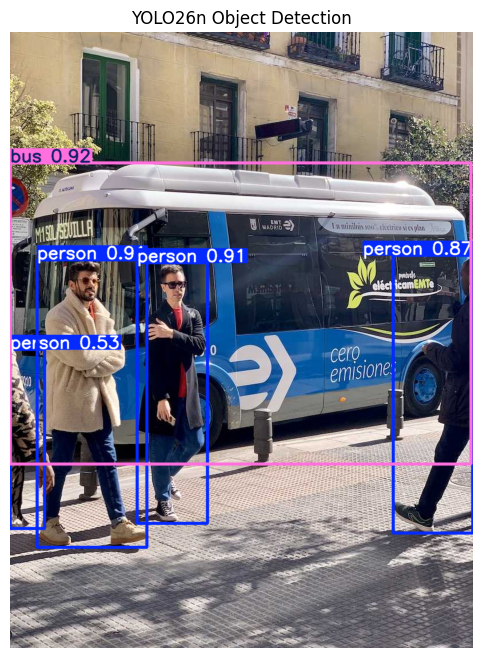

In [9]:
# DISPLAY DETECTION RESULT


print("=" * 60)
print("Displaying Detection Result")
print("=" * 60)

for result in results:

    annotated_image = result.plot()

    # Convert BGR to RGB for Matplotlib
    annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_image)
    plt.axis("off")
    plt.title("YOLO26n Object Detection")
    plt.show()

print("=" * 60)

# **Understanding what is actually returned**

In [10]:
# INSPECT DETECTION RESULTS

result = results[0]

print("=" * 60)
print("Detection Results")
print("=" * 60)

print("Number of Objects Detected :", len(result.boxes))

print("=" * 60)

for i, box in enumerate(result.boxes):

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = model.names[class_id]

    coordinates = box.xyxy[0].cpu().numpy()

    print(f"Object {i + 1}")
    print("Class      :", class_name)
    print("Confidence :", round(confidence, 3))
    print("Bounding Box:", coordinates)
    print("-" * 40)

print("=" * 60)

Detection Results
Number of Objects Detected : 5
Object 1
Class      : bus
Confidence : 0.924
Bounding Box: [          0      229.37       806.1      757.09]
----------------------------------------
Object 2
Class      : person
Confidence : 0.913
Bounding Box: [     222.47      404.94      345.41      861.64]
----------------------------------------
Object 3
Class      : person
Confidence : 0.905
Bounding Box: [     47.688      399.32      239.35      903.02]
----------------------------------------
Object 4
Class      : person
Confidence : 0.87
Bounding Box: [     670.68      391.53      809.81      878.98]
----------------------------------------
Object 5
Class      : person
Confidence : 0.534
Bounding Box: [    0.12922      556.69      60.004       870.1]
----------------------------------------


# **Filter for Autonomous Vehicle Objects**

In [11]:
# AUTONOMOUS VEHICLE RELEVANT OBJECTS

# Objects relevant to road-scene perception
target_classes = {
    "person",
    "car",
    "motorcycle",
    "bus",
    "truck",
    "bicycle",
    "traffic light",
    "stop sign"
}

print("=" * 60)
print("Autonomous Vehicle Object Analysis")
print("=" * 60)

detected_objects = []

for box in result.boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    if class_name in target_classes:

        detected_objects.append({
            "Object": class_name,
            "Confidence": round(confidence, 3)
        })

if detected_objects:

    detection_df = pd.DataFrame(detected_objects)

    print(detection_df)

else:

    print("No target autonomous-vehicle objects detected.")

print("=" * 60)

Autonomous Vehicle Object Analysis
   Object  Confidence
0     bus       0.924
1  person       0.913
2  person       0.905
3  person       0.870
4  person       0.534


In [12]:

# FIND UPLOADED VIDEO

import os

print("=" * 60)
print("Searching for Uploaded Video")
print("=" * 60)

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            print(os.path.join(root, file))

print("=" * 60)

Searching for Uploaded Video
/kaggle/input/datasets/anujadeore/road-traffic-mp4/road_trafifc.mp4


# **Upload Video**

In [13]:
# CHECK VIDEO INFORMATION

video_path = "/kaggle/input/datasets/anujadeore/road-traffic-mp4/road_trafifc.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("ERROR: Unable to open video.")
else:

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = frame_count / fps if fps > 0 else 0

    print("=" * 60)
    print("Video Information")
    print("=" * 60)

    print("Width          :", width)
    print("Height         :", height)
    print("Original FPS   :", round(fps, 2))
    print("Total Frames   :", frame_count)
    print("Duration       :", round(duration, 2), "seconds")

    print("=" * 60)

cap.release()

Video Information
Width          : 640
Height         : 360
Original FPS   : 29.97
Total Frames   : 301
Duration       : 10.04 seconds


# **Detect Objects in the Video**

In [14]:
# YOLO26 VIDEO OBJECT DETECTION

print("=" * 60)
print("Starting Video Object Detection")
print("=" * 60)

video_results = model.predict(
    source=video_path,
    conf=0.25,
    device=device,
    save=False,
    stream=True,
    verbose=False
)

print("Video Processing Started...")
print("=" * 60)

Starting Video Object Detection
Video Processing Started...


In [15]:
# ============================================================
# REAL-TIME YOLO26 VIDEO DETECTION
# WITH BOUNDING BOXES, FPS, COUNTING & WARNING
# ============================================================

import cv2
import os
import time
from collections import Counter

print("=" * 60)
print("YOLO26 REAL-TIME VIDEO DETECTION")
print("=" * 60)

# ------------------------------------------------------------
# Open input video
# ------------------------------------------------------------

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("ERROR: Could not open the input video.")

# ------------------------------------------------------------
# Get video properties
# ------------------------------------------------------------

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
original_fps = cap.get(cv2.CAP_PROP_FPS)

# ------------------------------------------------------------
# Create output video
# ------------------------------------------------------------

output_path = "/kaggle/working/yolo26_traffic_detection.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    original_fps,
    (width, height)
)

# ------------------------------------------------------------
# Variables
# ------------------------------------------------------------

frame_count = 0
total_detections = 0

target_classes = {
    "person",
    "car",
    "motorcycle",
    "bus",
    "truck",
    "bicycle",
    "traffic light",
    "stop sign"
}

start_time = time.time()

# ------------------------------------------------------------
# Process video frame-by-frame
# ------------------------------------------------------------

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    # --------------------------------------------------------
    # YOLO26 Detection
    # --------------------------------------------------------

    results = model.predict(
        source=frame,
        conf=0.40,
        device=device,
        verbose=False
    )

    result = results[0]

    # --------------------------------------------------------
    # Object Counter for Current Frame
    # --------------------------------------------------------

    current_objects = []

    # --------------------------------------------------------
    # Process detected objects
    # --------------------------------------------------------

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]

        if class_name not in target_classes:
            continue

        current_objects.append(class_name)
        total_detections += 1

        # Bounding box coordinates
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

        # ----------------------------------------------------
        # Draw Bounding Box
        # ----------------------------------------------------

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # ----------------------------------------------------
        # Display Class + Confidence
        # ----------------------------------------------------

        label = f"{class_name}: {confidence:.2f}"

        cv2.putText(
            frame,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    # --------------------------------------------------------
    # Calculate FPS
    # --------------------------------------------------------

    elapsed_time = time.time() - start_time

    current_fps = frame_count / elapsed_time if elapsed_time > 0 else 0

    # --------------------------------------------------------
    # Object Counting
    # --------------------------------------------------------

    object_counter = Counter(current_objects)

    y_position = 30

    cv2.putText(
        frame,
        f"FPS: {current_fps:.2f}",
        (20, y_position),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    y_position += 30

    # --------------------------------------------------------
    # Display Object Counts
    # --------------------------------------------------------

    for object_name, count in object_counter.items():

        text = f"{object_name}: {count}"

        cv2.putText(
            frame,
            text,
            (20, y_position),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2
        )

        y_position += 25

    # --------------------------------------------------------
    # Proximity Warning
    # --------------------------------------------------------

    warning = False

    frame_area = width * height

    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        if class_name not in target_classes:
            continue

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        object_area = (x2 - x1) * (y2 - y1)

        area_ratio = object_area / frame_area

        if area_ratio > 0.15:

            warning = True
            break

    # --------------------------------------------------------
    # Display Warning
    # --------------------------------------------------------

    if warning:

        cv2.putText(
            frame,
            "WARNING: OBJECT TOO CLOSE",
            (20, height - 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 0, 255),
            3
        )

    # --------------------------------------------------------
    # Write processed frame to output video
    # --------------------------------------------------------

    out.write(frame)


# ------------------------------------------------------------
# Release resources
# ------------------------------------------------------------

cap.release()
out.release()

total_time = time.time() - start_time

print("=" * 60)
print("VIDEO PROCESSING COMPLETED")
print("=" * 60)

print("Input Video       :", video_path)
print("Output Video      :", output_path)
print("Frames Processed  :", frame_count)
print("Total Detections  :", total_detections)
print("Processing Time   :", round(total_time, 2), "seconds")

if total_time > 0:
    print("Average FPS       :", round(frame_count / total_time, 2))

print("=" * 60)

YOLO26 REAL-TIME VIDEO DETECTION
VIDEO PROCESSING COMPLETED
Input Video       : /kaggle/input/datasets/anujadeore/road-traffic-mp4/road_trafifc.mp4
Output Video      : /kaggle/working/yolo26_traffic_detection.mp4
Frames Processed  : 301
Total Detections  : 1978
Processing Time   : 5.13 seconds
Average FPS       : 58.63


In [16]:
# OBJECT COUNTING FROM VIDEO

object_counts = {
    "person": 0,
    "car": 0,
    "motorcycle": 0,
    "bus": 0,
    "truck": 0,
    "bicycle": 0
}

frame_number = 0

print("=" * 60)
print("Counting Road Objects")
print("=" * 60)

for result in video_results:

    frame_number += 1

    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        if class_name in object_counts:
            object_counts[class_name] += 1

print("Video Processing Completed")

print("=" * 60)
print("Detection Counts")
print("=" * 60)

for object_name, count in object_counts.items():

    print(f"{object_name:<12} : {count}")

print("=" * 60)

Counting Road Objects
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Video Processing Completed
Detection Counts
person       : 285
car          : 1214
motorcycle   : 184
bus          : 264
truck        : 31
bicycle      : 0


In [17]:
# ============================================================
# CHECK OUTPUT VIDEO
# ============================================================

import os
import cv2

print("=" * 60)
print("Checking Output Video")
print("=" * 60)

print("File exists :", os.path.exists(output_path))

if os.path.exists(output_path):

    print("File size   :", round(os.path.getsize(output_path) / (1024 * 1024), 2), "MB")

    cap = cv2.VideoCapture(output_path)

    print("Video opened:", cap.isOpened())

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("Frames      :", frame_count)
    print("FPS         :", fps)
    print("Resolution  :", width, "x", height)

    cap.release()

print("=" * 60)

Checking Output Video
File exists : True
File size   : 8.86 MB
Video opened: True
Frames      : 301
FPS         : 29.97
Resolution  : 640 x 360


In [18]:
# ============================================================
# CONVERT OUTPUT VIDEO TO H.264 FORMAT
# ============================================================

import subprocess
import os

converted_video = "/kaggle/working/yolo26_traffic_detection_h264.mp4"

print("=" * 60)
print("Converting Video to Browser-Compatible Format")
print("=" * 60)

command = [
    "ffmpeg",
    "-y",
    "-i", output_path,
    "-vcodec", "libx264",
    "-pix_fmt", "yuv420p",
    "-acodec", "aac",
    converted_video
]

result = subprocess.run(
    command,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

if result.returncode == 0:

    print("Video conversion successful!")

else:

    print("Video conversion failed.")
    print(result.stderr[-2000:])

print("Output:", converted_video)
print("=" * 60)

Converting Video to Browser-Compatible Format
Video conversion successful!
Output: /kaggle/working/yolo26_traffic_detection_h264.mp4


In [19]:
# ============================================================
# DISPLAY H.264 VIDEO
# ============================================================

from IPython.display import Video, display

print("=" * 60)
print("YOLO26 Detection Output")
print("=" * 60)

display(
    Video(
        converted_video,
        embed=True,
        width=900
    )
)

print("=" * 60)

YOLO26 Detection Output


In [20]:
# YOLO26 OBJECT TRACKING

print("=" * 60)
print("Starting Object Tracking")
print("=" * 60)

track_results = model.track(
    source=video_path,
    conf=0.25,
    device=device,
    persist=True,
    stream=True,
    verbose=False
)

print("Tracking Initialized Successfully")
print("=" * 60)

Starting Object Tracking
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 363ms
 Downloaded lap
Prepared 1 package in 92ms
Installed 1 package in 6ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Tracking Initialized Successfully


In [21]:
# ANALYZE TRACKING IDs

unique_track_ids = set()

frame_number = 0

for result in track_results:

    frame_number += 1

    if result.boxes.id is not None:

        track_ids = result.boxes.id.int().cpu().tolist()

        for track_id in track_ids:
            unique_track_ids.add(track_id)

print("=" * 60)
print("Tracking Analysis")
print("=" * 60)

print("Frames Processed       :", frame_number)
print("Unique Objects Tracked :", len(unique_track_ids))

print("=" * 60)

Tracking Analysis
Frames Processed       : 301
Unique Objects Tracked : 21


# **Calculate Real-Time FPS**

In [22]:
# ============================================================
# REAL-TIME FPS MEASUREMENT
# ============================================================

print("=" * 60)
print("Measuring YOLO26 Inference Speed")
print("=" * 60)

cap = cv2.VideoCapture(video_path)

frame_count = 0

start_time = time.time()

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    # YOLO inference on current frame
    results = model.predict(
        source=frame,
        conf=0.25,
        device=device,
        verbose=False
    )

    frame_count += 1

end_time = time.time()

cap.release()

processing_time = end_time - start_time

fps = frame_count / processing_time

print("Frames Processed :", frame_count)
print("Processing Time  :", round(processing_time, 2), "seconds")
print("Average FPS      :", round(fps, 2))

print("=" * 60)

Measuring YOLO26 Inference Speed
Frames Processed : 301
Processing Time  : 10.25 seconds
Average FPS      : 29.37


In [23]:
# CONFIDENCE THRESHOLD EXPERIMENT

confidence_values = [0.25, 0.40, 0.50, 0.70]

confidence_results = []

print("=" * 60)
print("Confidence Threshold Experiment")
print("=" * 60)

for conf_threshold in confidence_values:

    detection_count = 0

    results = model.predict(
        source=video_path,
        conf=conf_threshold,
        device=device,
        stream=True,
        verbose=False
    )

    for result in results:

        detection_count += len(result.boxes)

    confidence_results.append({
        "Confidence Threshold": conf_threshold,
        "Total Detections": detection_count
    })

confidence_df = pd.DataFrame(confidence_results)

print(confidence_df)

print("=" * 60)

Confidence Threshold Experiment
   Confidence Threshold  Total Detections
0                  0.25              1379
1                  0.40              1220
2                  0.50              1112
3                  0.70               757


In [24]:
# PROXIMITY WARNING SYSTEM

print("=" * 60)
print("Proximity Warning Analysis")
print("=" * 60)

cap = cv2.VideoCapture(video_path)

frame_number = 0
warning_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    results = model.predict(
        source=frame,
        conf=0.40,
        device=device,
        verbose=False
    )

    result = results[0]

    frame_height, frame_width = frame.shape[:2]

    frame_area = frame_height * frame_width

    for box in result.boxes:

        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        object_width = x2 - x1
        object_height = y2 - y1

        object_area = object_width * object_height

        area_ratio = object_area / frame_area

        # Proximity heuristic
        if area_ratio > 0.15:

            warning_count += 1

            print(
                f"WARNING | Frame {frame_number} | "
                f"{class_name} appears close"
            )

    frame_number += 1

cap.release()

print("=" * 60)
print("Proximity Analysis Completed")
print("Potential Warnings :", warning_count)
print("=" * 60)

Proximity Warning Analysis
Proximity Analysis Completed
Potential Warnings : 0
